<a href="https://colab.research.google.com/github/dusandraq/Machine-Learning-Homework/blob/main/HW6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


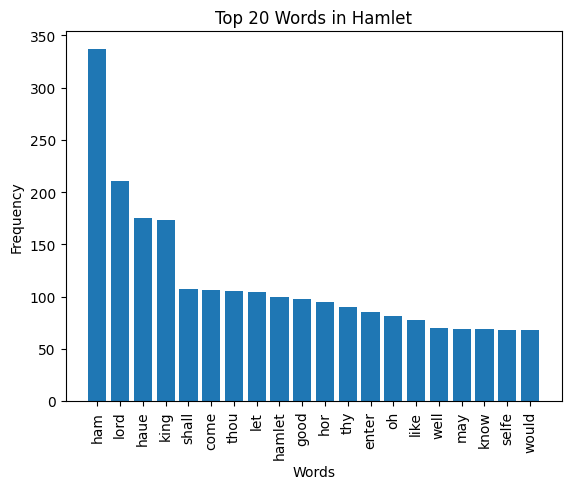

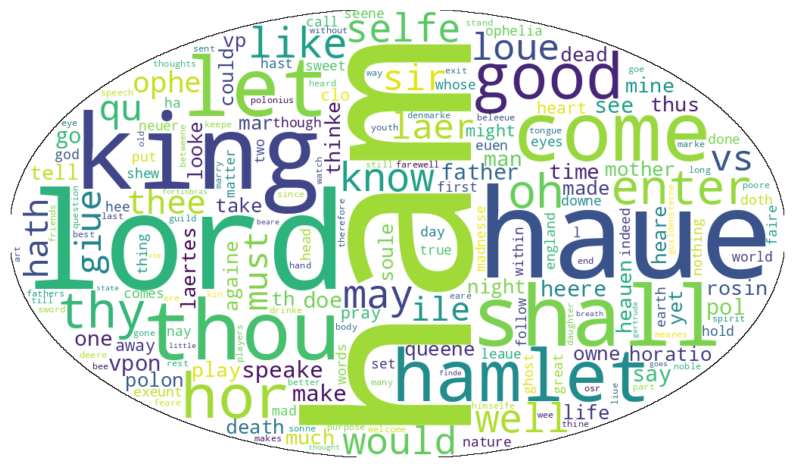

In [5]:
from numpy import imag
import nltk
import requests
from textblob import TextBlob
import matplotlib.pyplot as plt
import imageio
from wordcloud import WordCloud

#Download nltk resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab') # Added to resolve LookupError

#Get Hamlet text
target_URL = 'https://www.gutenberg.org/files/2265/2265-0.txt' # Corrected URL
response = requests.get(target_URL)
data = response.text

#Create Blob
blob = TextBlob(data)
stopWords = nltk.corpus.stopwords.words('english')

#Cleaning text
cleanWords = [word.lower() for word in blob.words if word.isalpha() and word.lower() not in stopWords]

#Frequency Distribution and top 20 words from clean text
fDistribution = nltk.FreqDist(cleanWords)
top20 = fDistribution.most_common(20)
words, counts = zip(*top20)
plt.bar(words, counts)
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('Top 20 Words in Hamlet')
plt.xticks(rotation=90)
plt.show()

image_file = "https://media.cheggcdn.com/media/216/21621ee5-e80f-47f3-9145-513f2229b390/phploeBuh.png"

mask_image = imageio.v3.imread(image_file)

wordcloud = WordCloud(
    background_color = "white",
    mask = mask_image,
    contour_width = 1,
    contour_color ="black"
).generate_from_frequencies(fDistribution)

plt.figure(figsize=(10,10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()